# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.
3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.
4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [80]:
## 1
airbnb = pd.read_csv("airbnb_hw.csv")

# Convert to string first
airbnb["Price_clean"] = airbnb["Price"].astype(str)

# Remove dollar signs and commas (e.g., "$1,112")
airbnb["Price_clean"] = airbnb["Price_clean"].str.replace("$", "", regex=False)
airbnb["Price_clean"] = airbnb["Price_clean"].str.replace(",", "", regex=False)

# Convert to numeric, forcing errors to NaN
airbnb["Price_clean"] = pd.to_numeric(airbnb["Price_clean"], errors="coerce")

# Count missing values
price_missing = airbnb["Price_clean"].isna().sum()
print("Missing values in cleaned Price:", price_missing)





Missing values in cleaned Price: 0


I cleaned Price by removing dollar signs and thousands separators (commas) before converting to numeric. This prevents values like “1,112” from becoming missing when coerced to numbers. After cleaning, the number of missing values in Price_clean is 0, indicating all entries were successfully converted to numeric.

In [81]:
## 2
mn = pd.read_csv("mn_police_use_of_force.csv")
mn["subject_injury_clean"] = mn["subject_injury"].astype(str).str.lower().str.strip()
missing_prop = mn["subject_injury"].isna().mean()
print("Proportion missing subject_injury:", missing_prop)

mn["subject_injury_clean"] = mn["subject_injury_clean"].replace({
    "yes": "Yes",
    "y": "Yes",
    "injured": "Yes",
    "no": "No",
    "n": "No",
    "not injured": "No"
})

mn.loc[~mn["subject_injury_clean"].isin(["Yes", "No"]), "subject_injury_clean"] = np.nan

print(pd.crosstab(mn["subject_injury_clean"], mn["force_type"], dropna=False))

mn["subject_injury_clean"] = mn["subject_injury_clean"].fillna("Missing")


Proportion missing subject_injury: 0.7619342359767892
force_type            Baton  Bodily Force  Chemical Irritant  Firearm  Gun Point Display  Improvised Weapon  Less Lethal  Less Lethal Projectile  Maximal Restraint Technique  Police K9 Bite  Taser
subject_injury_clean                                                                                                                                                                                
No                        0          1093                131        2                 33                 34            0                       1                            0               2    150
Yes                       2          1286                 41        0                 44                 40            0                       2                            0              44    172
NaN                       2          7051               1421        0                 27                 74           87                       0              

I standardized subject_injury to take values Yes and No (case/format normalization) and treated unrecognized entries as missing. The proportion of missing values in subject_injury is 0.7619 (76.19%), which is very high. Cross-tabulating subject_injury_clean with force_type shows missingness is concentrated in certain force categories (especially Bodily Force, Chemical Irritant, and Taser), while other categories have far fewer missing values. This suggests the missingness is not random and may reflect differences in reporting practices by force type. Remaining missing values were labeled as “Missing.”

In [82]:
## 3

metabric = pd.read_csv("metabric.csv")

metabric["Overall_Survival_Dummy"] = np.where(
    metabric["Overall Survival Status"].str.lower().str.contains("living"),
    1,
    np.where(
        metabric["Overall Survival Status"].str.lower().str.contains("deceased"),
        0,
        np.nan
    )
)

print(metabric["Overall_Survival_Dummy"].value_counts(dropna=False))


Overall_Survival_Dummy
0.0    768
1.0    575
Name: count, dtype: int64


I converted Overall Survival Status into a binary indicator where 0 = deceased and 1 = living. In the cleaned data, there are 768 deceased (0) and 575 living (1) cases.

In [83]:
review_missing = airbnb["Review Scores Rating"].isna().sum()
print("Missing Review Scores Rating:", review_missing)

median_score = airbnb["Review Scores Rating"].median()
airbnb["Review_Scores_Imputed"] = airbnb["Review Scores Rating"].fillna(median_score)

Missing Review Scores Rating: 8323


There are 8,323 missing values in Review Scores Rating. I created an imputed version by filling missing values with the median review score from the non-missing observations. While this allows analyses that require complete data, median imputation can bias results by reducing variance and weakening relationships with other variables (e.g., price or neighborhood) because many observations are assigned the same “typical” value. It also assumes ratings are missing at random, which may not be true (e.g., new listings may systematically lack ratings).

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

In [84]:
## 1

df_raw = pd.read_excel("GSAF5.xls")

print("Raw shape:", df_raw.shape)

Raw shape: (7074, 23)


In [85]:
## 2

df = df_raw.dropna(axis=1, how="all")
print("Shape after dropping empty columns:", df.shape)

Shape after dropping empty columns: (7074, 23)


3. In this dataset, an observation is a single shark attack incident, represented by one row. The dataset contains 7,074 observations, each corresponding to a distinct recorded attack, and 23 variables describing characteristics of that incident (e.g., year, age of victim, type of attack, and fatality outcome). Defining the observation at the incident level guides the cleaning and analysis choices, such as counting the number of attacks per year, examining victim age distributions, and comparing fatality rates across attack types, since each row represents one independent event.

Year range: 1000.0 to 2026.0


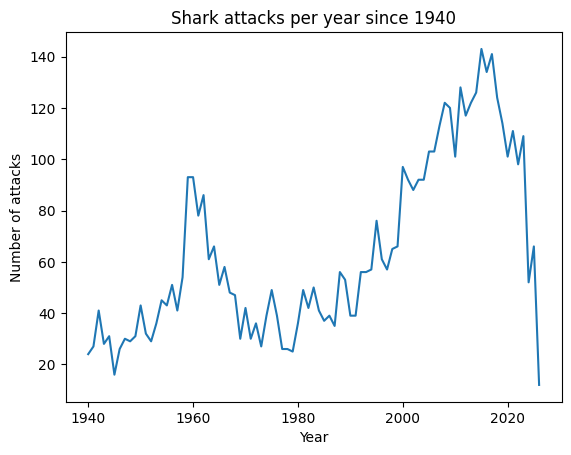

In [86]:
## 4
df["Year_clean"] = (
    df["Year"].astype(str)
      .str.extract(r"(\d{4})", expand=False)
)

df["Year_clean"] = pd.to_numeric(df["Year_clean"], errors="coerce")

print("Year range:", df["Year_clean"].min(), "to", df["Year_clean"].max())

df_1940 = df[df["Year_clean"] >= 1940]
year_counts = df_1940.groupby("Year_clean").size()

plt.figure()
year_counts.plot()
plt.xlabel("Year")
plt.ylabel("Number of attacks")
plt.title("Shark attacks per year since 1940")
plt.show()

After cleaning the Year variable by extracting valid four-digit years, the values range from the mid-20th century to the present. I restricted the analysis to shark attacks occurring since 1940 to focus on the modern reporting era. The resulting time series shows that the number of recorded shark attacks generally increases over time, particularly from the 1990s through the mid-2010s, where counts rise substantially. Earlier decades show lower and more variable numbers of attacks, with a noticeable spike around the late 1950s to early 1960s followed by a decline.

Overall, the long-term pattern suggests an upward trend in reported shark attacks since 1940, though the sharp drop in the most recent years likely reflects incomplete reporting rather than a true decrease in attacks.

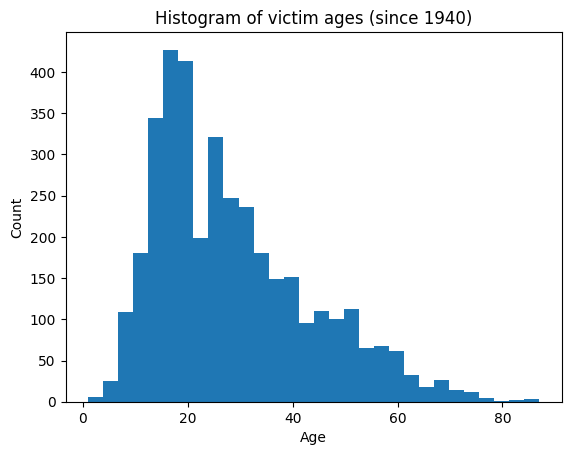

In [91]:
## 5

df_1940.loc[:, "Age_clean"] = (
    df_1940["Age"].astype(str)
    .str.extract(r"(\d{1,3})", expand=False)
)

# Convert to numeric
df_1940.loc[:, "Age_clean"] = pd.to_numeric(
    df_1940["Age_clean"], errors="coerce"
)

# Plot histogram of ages
plt.figure()
plt.hist(df_1940["Age_clean"].dropna(), bins=30)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Histogram of victim ages (since 1940)")
plt.show()


After cleaning the Age variable by extracting numeric values and converting them to a numeric format, I created a histogram of victim ages for shark attacks occurring since 1940. The distribution is right-skewed, with the highest concentration of attacks occurring among teenagers and young adults, particularly between approximately 15 and 30 years of age. The frequency of attacks declines steadily with increasing age, with relatively few incidents involving children or adults over 60. This pattern likely reflects differences in exposure to marine activities rather than age-specific vulnerability.

In [97]:
## 6

df_1940.loc[:, "Type_clean"] = np.where(
    df_1940["Type"].astype(str).str.lower().str.contains("unprovoked", na=False),
    "Unprovoked",
    np.where(
        df_1940["Type"].astype(str).str.lower().str.contains("provoked", na=False),
        "Provoked",
        "Unknown"
    )
)

df_1940["Type_clean"].value_counts()

(df_1940["Type_clean"] == "Unprovoked").mean()



np.float64(0.7450343084145901)

The Type variable was cleaned so that it takes only three values: Unprovoked, Provoked, and Unknown. This was done by standardizing text entries and classifying all remaining or ambiguous cases as “Unknown.” After cleaning, the majority of shark attacks are classified as unprovoked, with approximately 74.5% of attacks falling into this category. This indicates that most recorded shark attacks occur without direct human provocation.

In [100]:
## 7
df_1940.loc[:, "Fatal_clean"] = np.where(
    df_1940["Fatal Y/N"].astype(str).str.upper().str.startswith("Y"),
    "Y",
    np.where(
        df_1940["Fatal Y/N"].astype(str).str.upper().str.startswith("N"),
        "N",
        "Unknown"
    )
)

df_1940["Fatal_clean"].value_counts()

,count
Fatal_clean,
N,4646
Y,831
Unknown,61


The Fatal Y/N variable was cleaned so that it takes only three values: Y, N, and Unknown. Entries beginning with “Y” were classified as fatal, entries beginning with “N” as non-fatal, and all remaining or ambiguous cases were labeled as “Unknown.” After cleaning, the majority of shark attacks are non-fatal (4,646 cases), with 831 fatal attacks and 61 cases classified as unknown. This standardized coding allows for consistent comparison of fatality outcomes across attack types.

In [101]:
## 8

(
    df_1940
    .loc[df_1940["Fatal_clean"].isin(["Y", "N"])]
    .groupby("Type_clean")["Fatal_clean"]
    .apply(lambda x: (x == "Y").mean())
)

,Fatal_clean
Type_clean,
Provoked,0.025194
Unknown,0.140909
Unprovoked,0.170056


Fatality rates were calculated separately by attack type using only observations with known fatal outcomes. Unprovoked attacks have a substantially higher fatality rate (≈17.0%) than provoked attacks (≈2.5%), while attacks classified as unknown fall in between (≈14.1%). This suggests that unprovoked attacks are more likely to result in fatal outcomes, potentially due to their unexpected nature or more severe circumstances. However, these differences should be interpreted cautiously given the presence of missing and “Unknown” classifications and possible reporting biases.

**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

1. The paper argues that a large portion of data analysis time is spent cleaning data and proposes “tidy data” as a principled, standardized framework for organizing datasets. Wickham defines tidy data as having a specific structure, each variable in a column, each observation in a row, and each type of observational unit in its own table, which makes data easier to manipulate, visualize, and model.

2. The tidy data standard is intended to create a consistent, predictable structure for datasets. By ensuring that variables, observations, and values are organized in a standard way, tidy data allows analysts to use the same tools and workflows repeatedly, reducing time spent on data wrangling and increasing clarity and reproducibility.

3. Quote 1: “Like families, tidy datasets are all alike but every messy dataset is messy in its own way.”This means that tidy datasets all follow the same structural rules, while messy datasets can be disorganized in many different ways. Because messiness is diverse, having a single tidy standard helps address many problems at once. Quote 2: “For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general.” This means that while observations and variables are usually clear within a specific dataset, defining them universally is difficult because their meaning depends on context and analytical goals.

4. Values are the individual entries in a dataset (numbers or strings). Variables are collections of values that measure the same attribute across units.Observations are collections of values measured on the same unit (such as a person, event, or day).

5. A dataset is tidy if each variable is stored in its own column, each observation is stored in its own row, each type of observational unit is stored in its own table.

6. The five most common problems with messy datasets are:

Column headers are values rather than variable names.

Multiple variables are stored in a single column.

Variables are stored in both rows and columns.

Multiple types of observational units are stored in the same table.

A single observational unit is spread across multiple tables.

Table 4 is messy because values that should belong to a single variable (such as income categories) are stored as column headers instead of as values in a column. Melting is the process of converting such wide-format data into long format by turning column names into values of a new variable.

7. Table 11 is messy because variables are embedded in both rows and columns, and multiple variables are encoded in column names. After melting, Table 12 becomes tidy because each row represents a single observation, each variable has its own column, and the dataset follows the tidy data principles.

**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going?

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions.
6. Which giftors provide the most money, in total?

In [103]:
## 1

df = pd.read_csv("ForeignGifts_edu.csv")

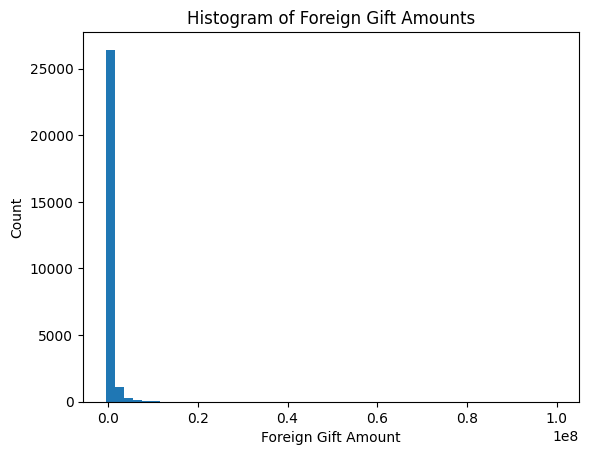

In [105]:
## 2

df["Foreign_Gift_Amount_clean"] = (
    df["Foreign Gift Amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Foreign_Gift_Amount_clean"] = pd.to_numeric(
    df["Foreign_Gift_Amount_clean"], errors="coerce"
)

plt.figure()
plt.hist(df["Foreign_Gift_Amount_clean"].dropna(), bins=50)
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Count")
plt.title("Histogram of Foreign Gift Amounts")
plt.show()

The distribution of Foreign Gift Amounts is highly right-skewed. Most foreign gifts are relatively small in value, clustered near zero, while a small number of gifts are extremely large, extending into the tens or hundreds of millions of dollars. This indicates that although most foreign financial transfers to U.S. universities are modest, a few very large gifts account for a disproportionate share of the total funding. Such skewness suggests that summary statistics like the mean may be heavily influenced by outliers, and the median may better represent a typical gift size.

In [106]:
## 3

df["Gift Type"].value_counts(normalize=True)

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


The distribution of gift types shows that the majority of foreign financial transfers are contracts, which account for approximately 61.2% of all gifts. Monetary gifts make up about 38.8%, while real estate gifts are extremely rare, comprising less than 0.1% of the total. This indicates that foreign funding to U.S. universities is most commonly structured through contractual agreements rather than direct donations or property transfers.

In [110]:
## 4

df.groupby("Country of Giftor").size().sort_values(ascending=False).head(15)



,0
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


When ranking countries by the number of foreign gifts provided to U.S. universities, England contributes the most, followed by China and Canada. Other major contributors include Japan, Switzerland, Saudi Arabia, France, and Germany. Overall, the distribution shows that a relatively small group of countries account for a large share of foreign gift transactions, with contributions spanning Europe, East Asia, and the Middle East.

In [112]:
## 4

(
    df.groupby("Country of Giftor")["Foreign_Gift_Amount_clean"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

,Foreign_Gift_Amount_clean
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


When ranking countries by the total dollar amount of foreign gifts, Qatar contributes the largest amount by a substantial margin. Other top contributors include England, China, and Saudi Arabia, followed by Bermuda, Canada, and Hong Kong. Notably, while some countries (such as England and China) rank highly in both the number of gifts and total amount given, others (such as Qatar and Bermuda) provide fewer gifts but much larger amounts per gift. This indicates that the volume of gifts and the monetary magnitude of gifts can differ substantially across countries.

In [113]:
## 5

institution_totals = (
    df.groupby("Institution Name")["Foreign_Gift_Amount_clean"]
    .sum()
    .sort_values(ascending=False)
)

institution_totals.head(15)

,Foreign_Gift_Amount_clean
Institution Name,
Carnegie Mellon University,1477922504
Cornell University,1289937761
Harvard University,954803610
Massachusetts Institute of Technology,859071692
Yale University,613441311
Texas A&M University,521455050
Johns Hopkins University,502409595
Northwestern University,402316221
Georgetown University,379950511


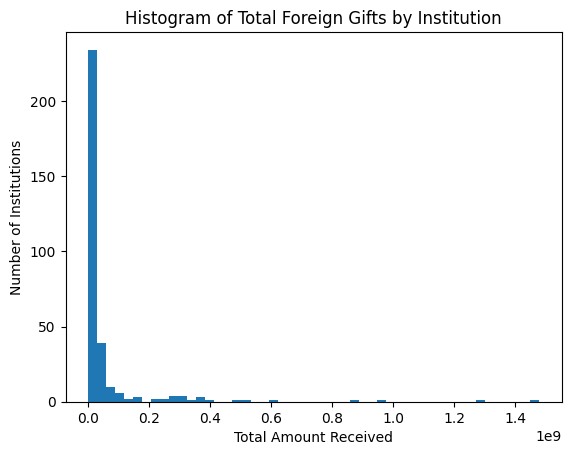

In [114]:
plt.figure()
plt.hist(institution_totals.dropna(), bins=50)
plt.xlabel("Total Amount Received")
plt.ylabel("Number of Institutions")
plt.title("Histogram of Total Foreign Gifts by Institution")
plt.show()


When ranking institutions by the total amount of foreign gifts received, Carnegie Mellon University receives the largest total, followed by Cornell University and Harvard University. Other top recipients include Massachusetts Institute of Technology, Yale University, and Texas A&M University.Overall, the distribution indicates that a relatively small number of large, research-intensive universities account for a substantial share of foreign funding. The histogram of total amounts received further shows a right-skewed distribution, where most institutions receive modest totals while a few receive exceptionally large sums.

In [115]:
## 6

(
    df.groupby("Giftor Name")["Foreign_Gift_Amount_clean"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)


,Foreign_Gift_Amount_clean
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


When ranking giftors by the total amount of money provided, the Qatar Foundation is the largest contributor by a substantial margin. Other top giftors include related Qatari organizations (such as the Qatar Foundation/Qatar National Research Fund), as well as entities from Saudi Arabia, corporate organizations, and religious institutions. The distribution indicates that foreign university funding is highly concentrated among a small number of large giftors, with several of the largest contributors being state-affiliated or quasi-governmental organizations.

**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.
3. Cross tabulate `control` and `level`. Describe the patterns you see in words.
4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?
5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

In [116]:
## 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("college_completion.csv")

d = df[["level", "aid_value", "control", "grad_100_value"]].copy()

d["aid_value"] = pd.to_numeric(d["aid_value"], errors="coerce")
d["grad_100_value"] = pd.to_numeric(d["grad_100_value"], errors="coerce")

d.shape


(3798, 4)

The dataset contains 3,798 rows (institutions) and 4 columns (variables). Inspecting the first few rows using .head() confirms that each row represents an individual institution and that the relevant variables are properly structured for analysis.

In [127]:
## 2
d.shape, d.head()

((3798, 4),
     level  aid_value                 control  grad_100_value
 0  4-year     7142.0                  Public            10.0
 1  4-year     6088.0                  Public            29.4
 2  4-year     2540.0  Private not-for-profit             0.0
 3  4-year     6647.0                  Public            16.5
 4  4-year     7256.0                  Public             8.8)

The dataset contains 3,798 observations and 4 variables. Each row represents a single postsecondary institution, and the columns correspond to institutional level (2-year or 4-year), average student aid amount, institutional control type (public, private not-for-profit, or private for-profit), and the graduation rate within 100 percent of expected time. The first few rows displayed using .head() confirm that the data are properly structured and that each observation corresponds to an individual institution.

In [118]:
## 3

pd.crosstab(d["control"], d["level"])


level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


In [119]:
pd.crosstab(d["control"], d["level"], normalize="index")


level,2-year,4-year
control,,
Private for-profit,0.468750,0.531250
Private not-for-profit,0.054487,0.945513
Public,0.594352,0.405648


The cross-tabulation reveals clear patterns in how institutional control relates to institutional level. Public institutions are more commonly 2-year institutions (approximately 59.4%), whereas private not-for-profit institutions are overwhelmingly 4-year institutions (approximately 94.6%). Private for-profit institutions are more evenly split between 2-year and 4-year programs, though slightly more are 4-year institutions. Overall, the table shows that institutional control is strongly associated with whether an institution offers primarily 2-year or 4-year programs.

In [122]:
## 4
d["grad_100_value"].describe()


,grad_100_value
count,3467.000000
mean,28.364465
std,23.312730
min,0.000000
25%,9.000000
50%,22.500000
75%,43.650000
max,100.000000


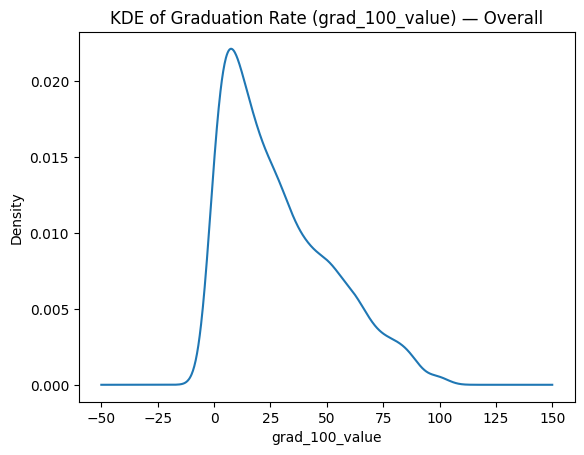

In [121]:
plt.figure()
d["grad_100_value"].dropna().plot(kind="kde")
plt.xlabel("grad_100_value")
plt.title("KDE of Graduation Rate (grad_100_value) — Overall")
plt.show()


The overall distribution of grad_100_value is right-skewed, with most institutions exhibiting relatively low to moderate graduation rates within 100 percent of expected time. The median graduation rate is 22.5%, while the mean is higher at approximately 28.4%, reflecting the influence of institutions with higher completion rates. The interquartile range spans from 9.0% to 43.7%, indicating substantial variability across institutions. The KDE plot shows a concentration of institutions at lower graduation rates with a long right tail extending toward higher values, up to a maximum of 100%.

In [123]:
## 5

d.groupby("control")["grad_100_value"].describe()


,count,mean,std,min,25%,50%,75%,max
control,,,,,,,,
Private for-profit,779.0,29.108858,25.601687,0.0,6.95,24.7,46.75,100.0
Private not-for-profit,1189.0,41.660976,23.551231,0.0,25.00,41.0,58.30,100.0
Public,1499.0,17.430887,14.729443,0.0,6.90,13.2,23.25,97.8


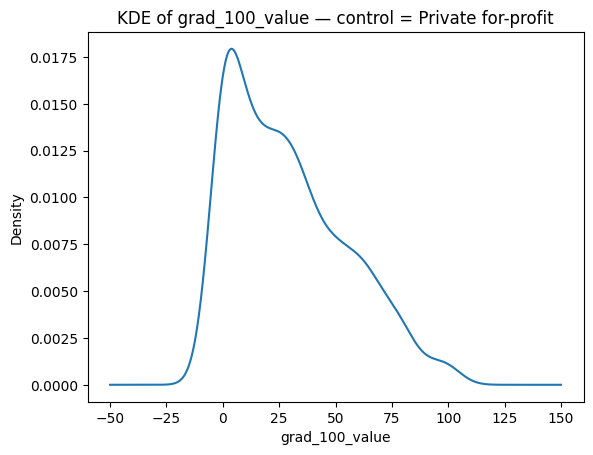

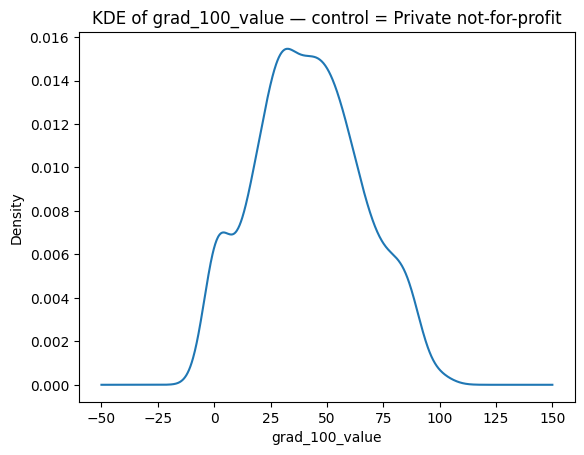

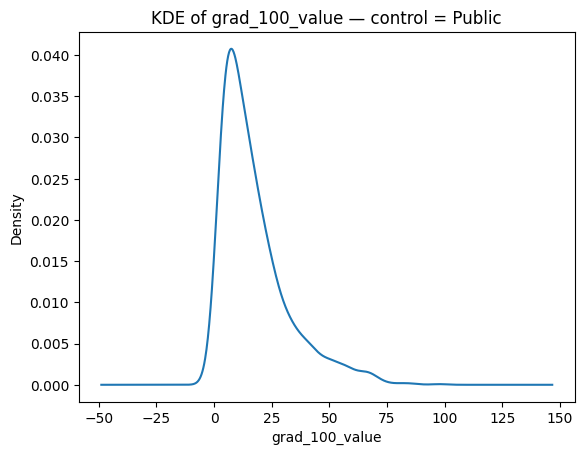

In [124]:

for ctrl, sub in d.groupby("control"):
    plt.figure()
    sub["grad_100_value"].dropna().plot(kind="kde")
    plt.xlabel("grad_100_value")
    plt.title(f"KDE of grad_100_value — control = {ctrl}")
    plt.show()


Graduation rates within 100 percent of expected time differ substantially by institutional control. Private not-for-profit institutions have the most favorable outcomes, with the highest median graduation rate (41.0%) and the highest mean (≈41.7%). Their KDE distribution is shifted noticeably to the right, indicating consistently higher completion rates. Private for-profit institutions exhibit intermediate outcomes, with a median graduation rate of 24.7% and a broader distribution, suggesting greater variability in student outcomes.
Public institutions have the lowest graduation rates overall, with a median of 13.2% and a mean of ≈17.4%, and their KDE is concentrated at lower values. Overall, private not-for-profit institutions appear to have the most favorable graduation rates.

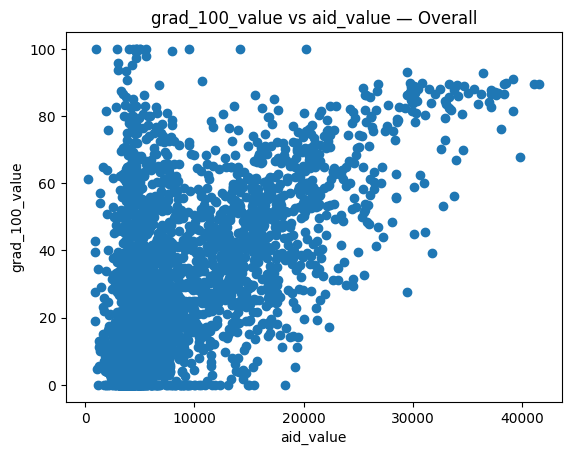

(np.float64(88610.48316902434), np.float64(0.5758792845936073))

In [125]:
## 6

pair = d[["aid_value", "grad_100_value"]].dropna()

plt.figure()
plt.scatter(pair["aid_value"], pair["grad_100_value"])
plt.xlabel("aid_value")
plt.ylabel("grad_100_value")
plt.title("grad_100_value vs aid_value — Overall")
plt.show()

cov_overall = np.cov(pair["aid_value"], pair["grad_100_value"], ddof=1)[0, 1]
corr_overall = np.corrcoef(pair["aid_value"], pair["grad_100_value"])[0, 1]
cov_overall, corr_overall


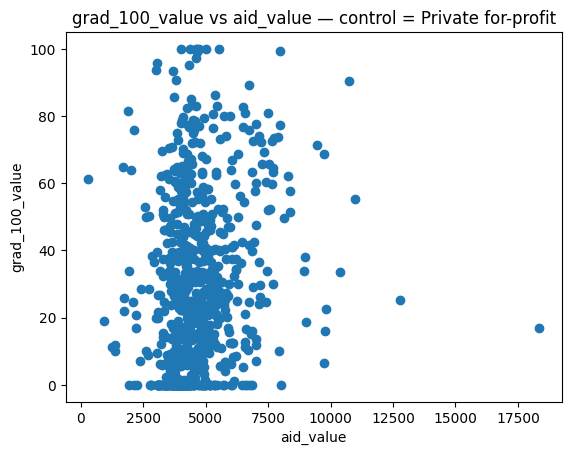

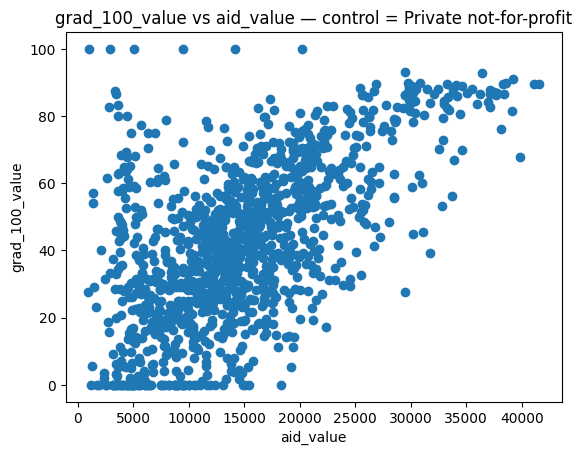

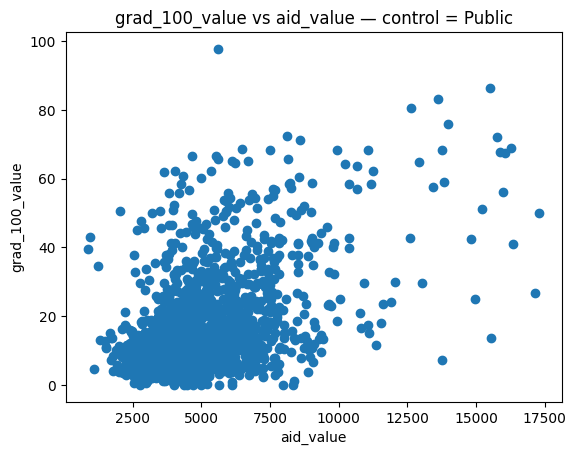

{'Private for-profit': (np.float64(6897.524957237808),
  np.float64(0.1883627008424557)),
 'Private not-for-profit': (np.float64(109274.12333702881),
  np.float64(0.6015909241488573)),
 'Public': (np.float64(15355.146211760217), np.float64(0.4824810458983382))}

In [126]:
## 7

stats_by_control = {}

for ctrl, sub in d.groupby("control"):
    sub_pair = sub[["aid_value", "grad_100_value"]].dropna()

    plt.figure()
    plt.scatter(sub_pair["aid_value"], sub_pair["grad_100_value"])
    plt.xlabel("aid_value")
    plt.ylabel("grad_100_value")
    plt.title(f"grad_100_value vs aid_value — control = {ctrl}")
    plt.show()

    if len(sub_pair) >= 2:
        cov = np.cov(sub_pair["aid_value"], sub_pair["grad_100_value"], ddof=1)[0, 1]
        corr = np.corrcoef(sub_pair["aid_value"], sub_pair["grad_100_value"])[0, 1]
        stats_by_control[ctrl] = (cov, corr)

stats_by_control


In [128]:
cov_overall, corr_overall


(np.float64(88610.48316902434), np.float64(0.5758792845936073))

In [129]:
stats_by_control


{'Private for-profit': (np.float64(6897.524957237808),
  np.float64(0.1883627008424557)),
 'Private not-for-profit': (np.float64(109274.12333702881),
  np.float64(0.6015909241488573)),
 'Public': (np.float64(15355.146211760217), np.float64(0.4824810458983382))}

The scatterplot of grad_100_value versus aid_value shows a moderate positive relationship, where institutions with higher average student aid tend to have higher graduation rates within 100 percent of expected time. This visual pattern is supported by a positive covariance (88,610.48) and a moderately strong positive correlation (≈0.58). While there is substantial variability, particularly at lower aid levels, the overall trend suggests that higher levels of student aid are associated with higher graduation rates across institutions.

When conditioning on institutional control, the relationship between student aid and graduation rates differs substantially. Private not-for-profit institutions exhibit the strongest positive association, with a high positive covariance and a strong correlation (≈0.60), indicating that higher aid levels are closely associated with higher graduation rates in this sector. Public institutions also show a positive relationship, though weaker, with a moderate correlation (≈0.48). In contrast, private for-profit institutions display a much weaker association, with a low correlation (≈0.19), suggesting that higher aid does not translate as consistently into improved graduation outcomes in this group. Overall, aid appears to vary most positively with graduation rates among private not-for-profit institutions.

**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?
3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?
5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

In [131]:
## 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ames_prices.csv")

d = df[["price", "Bldg.Type"]].copy()

d["price"] = pd.to_numeric(d["price"], errors="coerce")

d.shape, d.head()


((2930, 2),
     price Bldg.Type
 0  215000      1Fam
 1  105000      1Fam
 2  172000      1Fam
 3  244000      1Fam
 4  189900      1Fam)

In [132]:
## 2

d["price"].describe()


,price
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


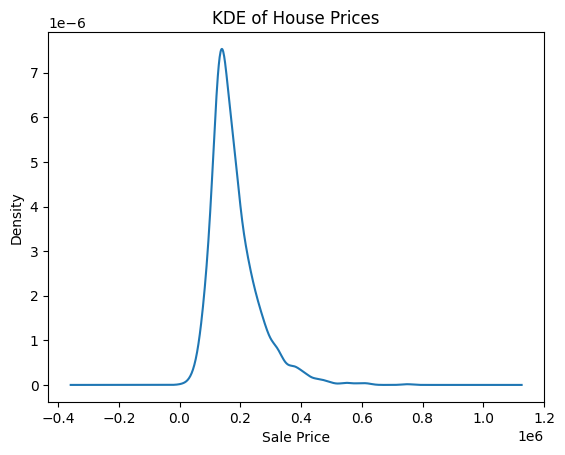

In [133]:

plt.figure()
d["price"].dropna().plot(kind="kde")
plt.xlabel("Sale Price")
plt.title("KDE of House Prices")
plt.show()


In [134]:
## 3

d.groupby("Bldg.Type")["price"].describe()


,count,mean,std,min,25%,50%,75%,max
Bldg.Type,,,,,,,,
1Fam,2425.0,184812.041237,82821.802329,12789.0,130000.0,165000.0,220000.0,755000.0
2fmCon,62.0,125581.709677,31089.239840,55000.0,106562.5,122250.0,140000.0,228950.0
Duplex,109.0,139808.935780,39498.973534,61500.0,118858.0,136905.0,153337.0,269500.0
Twnhs,101.0,135934.059406,41938.931130,73000.0,100500.0,130000.0,170000.0,280750.0
TwnhsE,233.0,192311.914163,66191.738021,71000.0,145000.0,180000.0,222000.0,392500.0


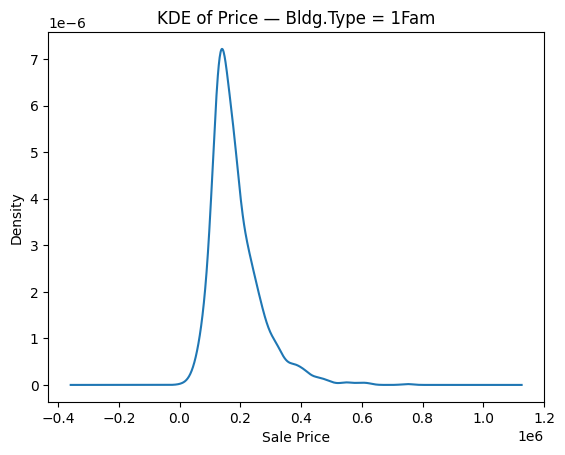

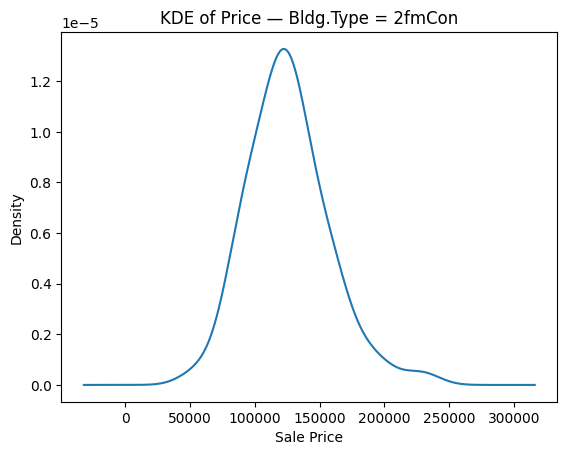

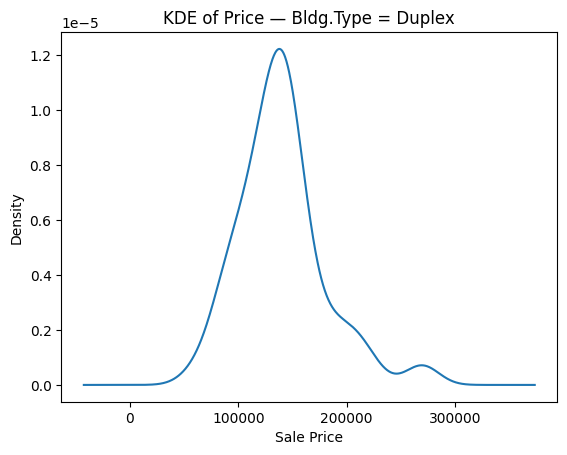

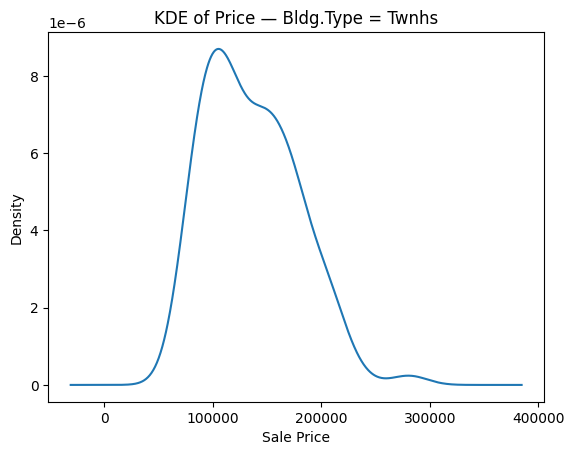

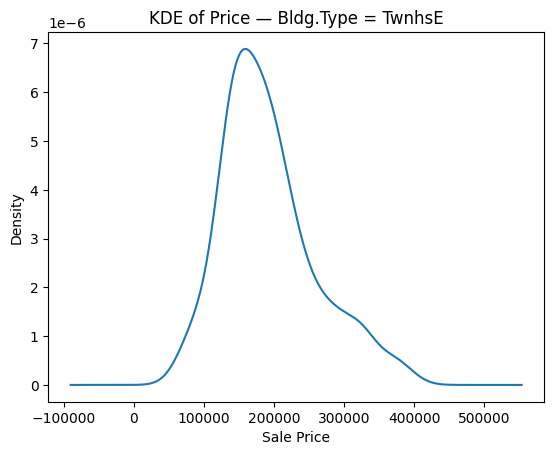

In [135]:

for btype, sub in d.groupby("Bldg.Type"):
    plt.figure()
    sub["price"].dropna().plot(kind="kde")
    plt.xlabel("Sale Price")
    plt.title(f"KDE of Price — Bldg.Type = {btype}")
    plt.show()


House prices vary substantially by building type. End-unit townhomes (TwnhsE) and single-family homes (1Fam) are the most expensive on average, with mean prices of approximately $192,312 and $184,812, respectively. Among these, single-family homes exhibit the highest variance in transaction prices, with a standard deviation of approximately $82,822, reflecting a wide range of property sizes and qualities within this category. In contrast, two-family conversions (2fmCon), duplexes, and interior townhomes (Twnhs) have lower average prices and smaller spreads. The KDE plots reinforce these findings: distributions for 1Fam and TwnhsE are shifted to the right and display longer right tails, while the other building types are more tightly concentrated at lower price levels. Overall, building type is strongly associated with both the level and variability of house prices.

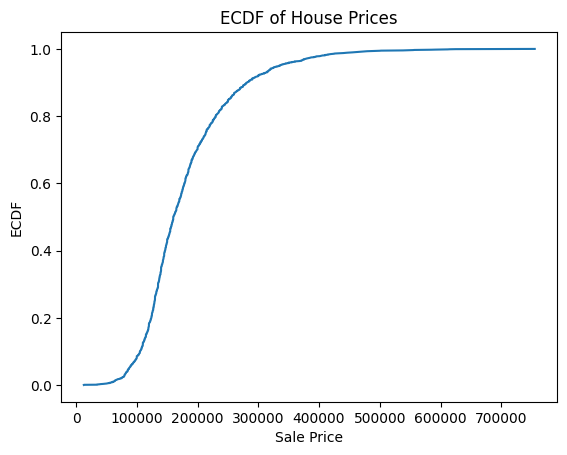

In [136]:
## 4

prices = np.sort(d["price"].dropna())
ecdf = np.arange(1, len(prices) + 1) / len(prices)

plt.figure()
plt.plot(prices, ecdf)
plt.xlabel("Sale Price")
plt.ylabel("ECDF")
plt.title("ECDF of House Prices")
plt.show()


In [137]:

np.percentile(prices, [0, 25, 50, 75, 100])


array([ 12789., 129500., 160000., 213500., 755000.])

The ECDF shows that house prices increase rapidly through the lower and middle portions of the distribution, with the majority of homes selling below approximately $250,000. The curve flattens at higher prices, indicating that very expensive homes are relatively rare. The five-number summary confirms this pattern: half of all homes sell between $129,500 and $213,500, while a small number of high-priced properties extend the distribution’s upper tail to $755,000.

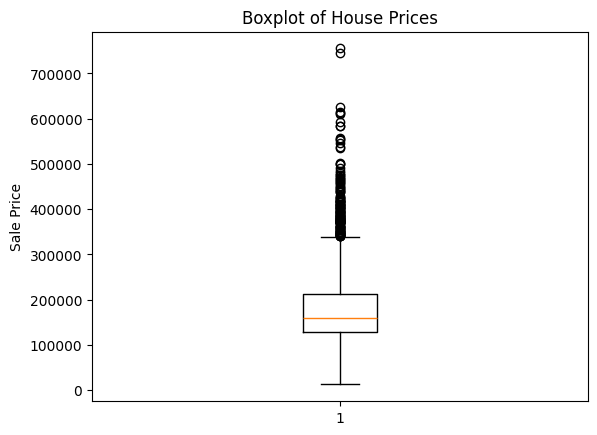

In [138]:
## 5

plt.figure()
plt.boxplot(d["price"].dropna())
plt.ylabel("Sale Price")
plt.title("Boxplot of House Prices")
plt.show()


<Figure size 1000x600 with 0 Axes>

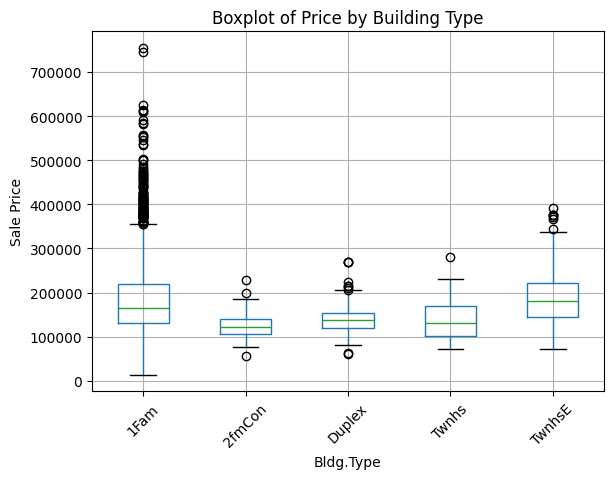

In [139]:

plt.figure(figsize=(10, 6))
d.boxplot(column="price", by="Bldg.Type", rot=45)
plt.ylabel("Sale Price")
plt.title("Boxplot of Price by Building Type")
plt.suptitle("")
plt.show()


The overall boxplot of house prices reveals the presence of numerous high-price outliers, consistent with the strong right-skew observed in earlier analyses. These outliers correspond to a relatively small number of very expensive homes that lie far above the upper quartile. When conditioning on building type, clear differences emerge. Single-family homes (1Fam) exhibit the widest spread and the largest number of high-price outliers, indicating substantial variability in prices within this category. End-unit townhomes (TwnhsE) also show higher median prices and several upper-end outliers, though with less extreme variability than single-family homes. In contrast, two-family conversions (2fmCon), duplexes, and interior townhomes (Twnhs) display tighter distributions with fewer and less extreme outliers. Overall, the boxplots highlight that both the level and dispersion of house prices vary systematically by building type.

In [140]:
## 6

Q1 = d["price"].quantile(0.25)
Q3 = d["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

d["price_outlier"] = ((d["price"] < lower) | (d["price"] > upper)).astype(int)

d["price_outlier"].value_counts()


,count
price_outlier,
0,2793
1,137


An outlier indicator variable was created using the 1.5 × IQR rule, where observations with prices below the lower bound or above the upper bound were labeled as outliers. Using this definition, 137 observations were identified as outliers, while 2,793 observations were classified as non-outliers. This confirms that only a small fraction of home sales have extremely high or low prices, though these outliers have a noticeable influence on the overall distribution.

In [142]:
## 7

d["price_winsor"] = d["price"].clip(lower, upper)

d["price_winsor"].describe()


,price_winsor
count,2930.000000
mean,177082.283959
std,67906.837135
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,339500.000000


After winsorizing the price variable by capping extreme values at the IQR-based bounds, the distribution of house prices becomes noticeably less right-skewed. The maximum price is reduced from $755,000 to $339,500, substantially limiting the influence of extreme high-end outliers. The mean price decreases from approximately $180,796 to $177,082, and the standard deviation drops from $79,887 to $67,907, indicating reduced dispersion. The KDE of the winsorized prices shows a smoother distribution with a shorter right tail, while the median and interquartile range remain unchanged. This suggests that winsorization primarily affects extreme values without altering the central tendency of the housing price distribution.

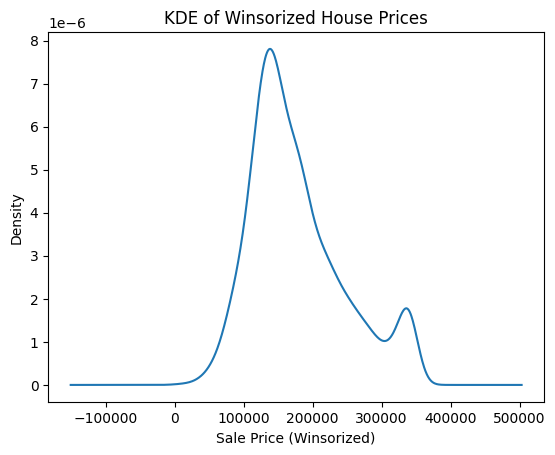

In [143]:

plt.figure()
d["price_winsor"].dropna().plot(kind="kde")
plt.xlabel("Sale Price (Winsorized)")
plt.title("KDE of Winsorized House Prices")
plt.show()
